# Customer Churn — Explainability

## Business objective
The goal of this notebook is to explain the final churn model and translate its predictions into business-relevant insights.

## Notebook objectives
This notebook focuses on:
1. explaining the final XGBoost model,
2. identifying the main factors that increase churn risk,
3. identifying the factors that reduce churn risk,
4. analyzing the profile of the highest-risk customers,
5. using SHAP for both global and local interpretability,
6. producing outputs that can later be reused in the dashboard and README.

## Explainability scope
This notebook combines:
- model-level feature importance,
- SHAP global importance,
- SHAP local explanations,
- cohort analysis on high-risk customers.

The aim is not only to rank features, but to explain what the model is actually learning about churn.

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_FIGURES = False
RANDOM_STATE = 42


def save_fig(filename: str) -> None:
    if EXPORT_FIGURES:
        plt.savefig(FIGURES_DIR / filename, bbox_inches="tight", dpi=300)

## 1. Load the final modeling artifact and the engineered datasets

We reuse the final artifact saved in the modeling notebook, along with the engineered train / validation / test datasets.

In [25]:
artifact = joblib.load(MODELS_DIR / "final_model_artifact.joblib")

train_df = pd.read_csv(DATA_DIR / "train_engineered.csv")
valid_df = pd.read_csv(DATA_DIR / "validation_engineered.csv")
test_df = pd.read_csv(DATA_DIR / "test_engineered.csv")

print("Loaded model:", artifact["model_name"])
print("Validation-selected threshold:", artifact["threshold"])
print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Loaded model: XGBoost
Validation-selected threshold: 0.5199999999999998
Train shape: (4929, 28)
Validation shape: (1057, 28)
Test shape: (1057, 28)


In [26]:
TARGET_COL = "churn"

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_valid = valid_df.drop(columns=[TARGET_COL]).copy()
y_valid = valid_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

X_train_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

final_pipeline = artifact["pipeline"]
model_name = artifact["model_name"]

fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]

feature_names = artifact.get("feature_names", fitted_preprocessor.get_feature_names_out())
feature_names = list(feature_names)

print("Final model:", model_name)
print("Number of transformed features:", len(feature_names))

Final model: XGBoost
Number of transformed features: 57


## 2. Recompute scores on the test set

Explainability is mostly based on predicted probabilities and feature contributions, not only on hard class labels.

For interpretation purposes, we keep the default threshold of 0.50 as the main operating point, because it was slightly stronger on the test set in the previous notebook.

In [27]:
ANALYSIS_THRESHOLD = 0.50
VALIDATION_SELECTED_THRESHOLD = artifact["threshold"]

y_test_score = final_pipeline.predict_proba(X_test)[:, 1]

test_analysis = X_test.copy()
test_analysis["churn"] = y_test.values
test_analysis["score"] = y_test_score
test_analysis["pred_default_050"] = (test_analysis["score"] >= ANALYSIS_THRESHOLD).astype(int)
test_analysis["pred_validation_threshold"] = (
    test_analysis["score"] >= VALIDATION_SELECTED_THRESHOLD
).astype(int)

test_analysis.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,tenure_group,long_contract,high_monthly_charges,avg_monthly_value_proxy,subscribed_services_count,payment_group,has_security_bundle,fiber_optic_customer,churn,score,pred_default_050,pred_validation_threshold
0,Female,1,No,No,65,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),53.5000,"3,517.9000",long_term,1,0,54.1215,4,automatic,1,0,0,0.1483,0,0
1,Male,0,Yes,No,52,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),95.6500,"5,088.4000",long_term,0,1,97.8538,3,automatic,1,1,0,0.3355,0,0
2,Female,1,No,No,69,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),110.2500,"7,467.5500",long_term,1,1,108.2254,5,automatic,1,1,0,0.2430,0,0
3,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1000,"1,949.4000",mid_term,0,1,88.6091,2,automatic,0,1,0,0.6698,1,1
4,Male,1,Yes,No,46,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.8500,"4,564.9000",long_term,0,1,99.2370,3,electronic_check,1,1,0,0.8384,1,1


In [28]:
artifact["test_results"].round(4)

,setting,threshold,roc_auc,pr_auc,precision,recall,f1,recall_at_top10pct,predicted_positive_rate
0,default_0.50,0.5000,0.8482,0.6519,0.5274,0.7893,0.6323,0.2750,0.3964
1,tuned_0.52,0.5200,0.8482,0.6519,0.5338,0.7607,0.6274,0.2750,0.3775


## 3. Global feature importance from XGBoost

We first inspect the built-in feature importance from the final XGBoost model.

This gives a first view of which transformed features the model relies on most. However, because some engineered features partly overlap with original variables, these importances should be interpreted carefully and later complemented with SHAP.

In [29]:
model_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

model_importance_df.head(15)

,feature,importance
6,num__long_contract,0.2606
42,cat__contract_Month-to-month,0.1544
22,cat__internet_service_Fiber optic,0.0953
9,num__fiber_optic_customer,0.0509
33,cat__tech_support_No,0.0482
53,cat__tenure_group_new,0.0305
24,cat__online_security_No,0.0264
41,cat__streaming_movies_Yes,0.0203
44,cat__contract_Two year,0.0183
51,cat__tenure_group_long_term,0.0147


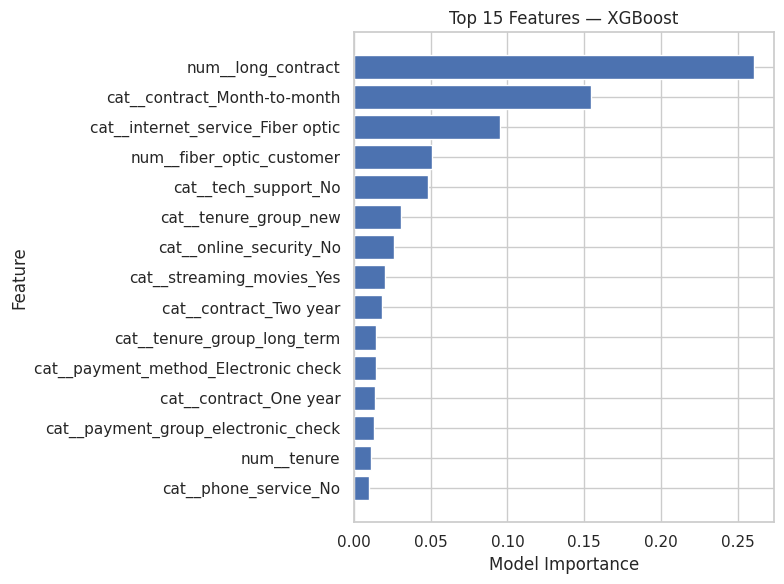

In [30]:
top_n = 15
plot_df = model_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top {top_n} Features — {model_name}")
plt.xlabel("Model Importance")
plt.ylabel("Feature")
plt.tight_layout()
save_fig("explainability_01_model_importance.png")
plt.show()

## 3.1 Interpretation note on feature redundancy

Some engineered features partially overlap with original variables:
- `long_contract` and `contract`,
- `fiber_optic_customer` and `internet_service`,
- `payment_group` and `payment_method`,
- `tenure_group` and `tenure`.

This is acceptable for predictive performance, but it means that importance should be interpreted mainly at the **theme level** rather than as a perfectly independent ranking of variables.

In [31]:
def assign_feature_family(feature: str) -> str:
    if "contract" in feature:
        return "contract"
    if "tenure_group" in feature or feature == "num__tenure":
        return "tenure"
    if "internet_service" in feature or "fiber_optic_customer" in feature:
        return "internet"
    if "payment_method" in feature or "payment_group" in feature:
        return "payment"
    if (
        "tech_support" in feature
        or "online_security" in feature
        or "online_backup" in feature
        or "device_protection" in feature
        or "has_security_bundle" in feature
    ):
        return "support_security"
    if (
        "monthly_charges" in feature
        or "total_charges" in feature
        or "avg_monthly_value_proxy" in feature
        or "high_monthly_charges" in feature
    ):
        return "billing"
    if (
        "streaming" in feature
        or "subscribed_services_count" in feature
        or "phone_service" in feature
        or "multiple_lines" in feature
    ):
        return "service_adoption"
    if (
        "gender" in feature
        or "senior_citizen" in feature
        or "partner" in feature
        or "dependents" in feature
    ):
        return "demographics"
    return "other"


model_importance_df["feature_family"] = model_importance_df["feature"].apply(assign_feature_family)

family_importance_df = (
    model_importance_df.groupby("feature_family", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

family_importance_df

,feature_family,importance
1,contract,0.4468
3,internet,0.1545
7,support_security,0.1175
6,service_adoption,0.0864
8,tenure,0.0613
5,payment,0.0536
2,demographics,0.0364
0,billing,0.0269
4,other,0.0167


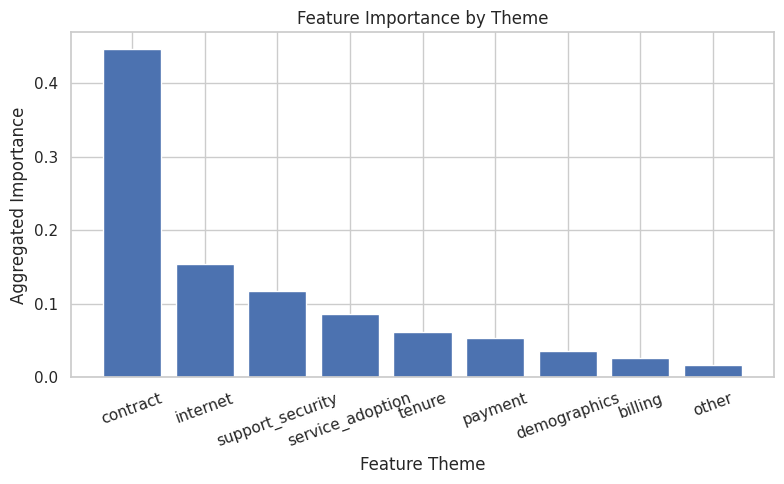

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(family_importance_df["feature_family"], family_importance_df["importance"])
plt.title("Feature Importance by Theme")
plt.xlabel("Feature Theme")
plt.ylabel("Aggregated Importance")
plt.xticks(rotation=20)
plt.tight_layout()
save_fig("explainability_02_feature_family_importance.png")
plt.show()

## 4. Build the transformed datasets for SHAP

SHAP is computed on the transformed feature space used by the final pipeline.

In [33]:
X_train_full_processed = pd.DataFrame(
    fitted_preprocessor.transform(X_train_full),
    columns=feature_names,
    index=X_train_full.index,
)

X_test_processed = pd.DataFrame(
    fitted_preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)

print("Processed full-train shape:", X_train_full_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed full-train shape: (5986, 57)
Processed test shape: (1057, 57)


In [34]:
import xgboost as xgb

X_test_shap = X_test_processed.copy()

booster = fitted_model.get_booster()

def build_shap_explanation_xgb_native(booster, X_explain: pd.DataFrame) -> shap.Explanation:
    """
    Build SHAP-like explanations directly from XGBoost native pred_contribs.
    This avoids compatibility issues with shap.TreeExplainer on some SHAP/XGBoost versions.
    """
    dmatrix = xgb.DMatrix(
        X_explain,
        feature_names=X_explain.columns.tolist()
    )

    contribs = booster.predict(dmatrix, pred_contribs=True)

    # XGBoost returns one extra column for the bias term
    shap_values = contribs[:, :-1]
    base_values = contribs[:, -1]

    return shap.Explanation(
        values=shap_values,
        base_values=base_values,
        data=X_explain.values,
        feature_names=X_explain.columns.tolist(),
    )

shap_explanation = build_shap_explanation_xgb_native(
    booster,
    X_test_shap,
)

print("SHAP explanation built successfully.")
print("Explained rows:", len(X_test_shap))
print("Explained columns:", X_test_shap.shape[1])

SHAP explanation built successfully.
Explained rows: 1057
Explained columns: 57


## 5. Global SHAP importance

We now compute mean absolute SHAP values, which provide a more reliable global ranking of feature influence than built-in tree importance alone.

In [35]:
global_shap_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_explanation.values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

global_shap_importance["feature_family"] = global_shap_importance["feature"].apply(assign_feature_family)

global_shap_importance.head(15)

,feature,mean_abs_shap,feature_family
6,num__long_contract,0.6495,contract
1,num__tenure,0.4093,tenure
3,num__total_charges,0.2167,billing
9,num__fiber_optic_customer,0.2130,internet
24,cat__online_security_No,0.1924,support_security
33,cat__tech_support_No,0.1898,support_security
2,num__monthly_charges,0.1896,billing
4,num__avg_monthly_value_proxy,0.1748,billing
49,cat__payment_method_Electronic check,0.1346,payment
44,cat__contract_Two year,0.1323,contract


In [51]:
top_driver_summary = global_shap_importance.head(10).copy()
top_driver_summary["mean_abs_shap"] = top_driver_summary["mean_abs_shap"].round(4)
top_driver_summary

,feature,mean_abs_shap,feature_family
6,num__long_contract,0.6495,contract
1,num__tenure,0.4093,tenure
3,num__total_charges,0.2167,billing
9,num__fiber_optic_customer,0.2130,internet
24,cat__online_security_No,0.1924,support_security
33,cat__tech_support_No,0.1898,support_security
2,num__monthly_charges,0.1896,billing
4,num__avg_monthly_value_proxy,0.1748,billing
49,cat__payment_method_Electronic check,0.1346,payment
44,cat__contract_Two year,0.1323,contract


The SHAP ranking confirms that contract commitment and customer tenure dominate the model's decision process. Billing, support/security signals, internet configuration, and payment behavior form the next most important explanatory layers.

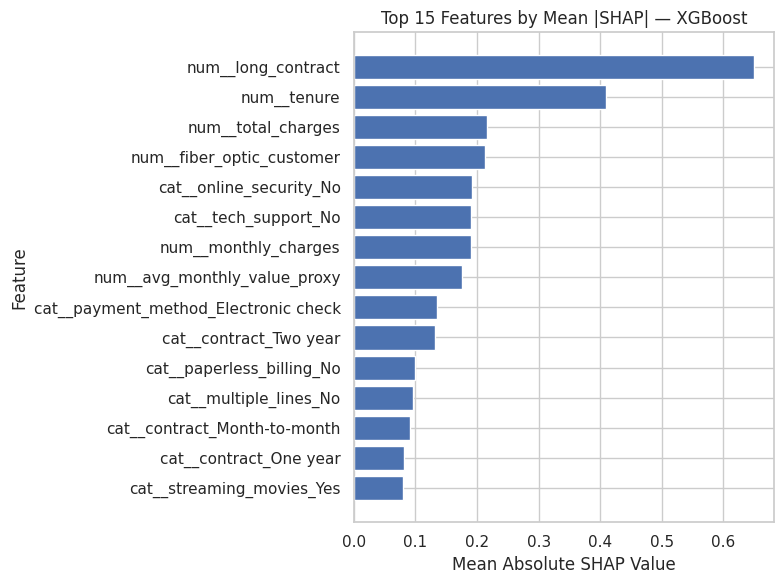

In [36]:
top_n = 15
plot_df = global_shap_importance.head(top_n).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.title(f"Top {top_n} Features by Mean |SHAP| — {model_name}")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
save_fig("explainability_03_global_shap_importance.png")
plt.show()

In [37]:
global_shap_family = (
    global_shap_importance.groupby("feature_family", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

global_shap_family

,feature_family,mean_abs_shap
1,contract,0.9541
0,billing,0.5928
7,support_security,0.5606
8,tenure,0.4502
6,service_adoption,0.3315
5,payment,0.2761
3,internet,0.2645
2,demographics,0.1654
4,other,0.1332


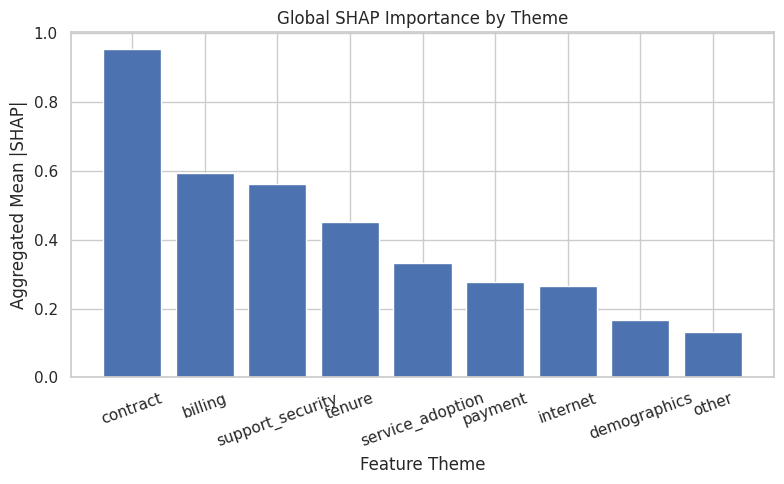

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(global_shap_family["feature_family"], global_shap_family["mean_abs_shap"])
plt.title("Global SHAP Importance by Theme")
plt.xlabel("Feature Theme")
plt.ylabel("Aggregated Mean |SHAP|")
plt.xticks(rotation=20)
plt.tight_layout()
save_fig("explainability_04_global_shap_family_importance.png")
plt.show()

## 6. SHAP summary plot

The SHAP summary plot shows both:
- feature importance,
- and the direction of impact across customers.

Features pushing predictions to the right increase churn risk; features pushing them to the left reduce it.

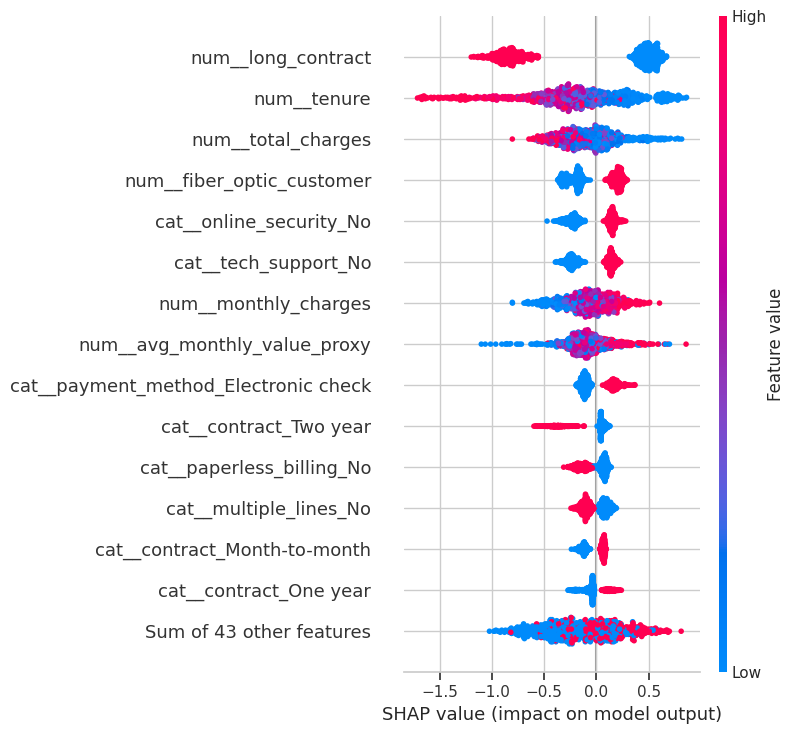

In [39]:
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.tight_layout()
save_fig("explainability_05_shap_beeswarm.png")
plt.show()

## 7. High-risk vs low-risk customer cohorts

To make the explainability more business-oriented, we compare the profile of:
- the top 10% highest-risk customers,
- the bottom 10% lowest-risk customers,
- the full test population.

This helps identify which customer profiles are most sensitive.

In [40]:
test_analysis["risk_decile"] = pd.qcut(
    test_analysis["score"].rank(method="first"),
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

test_analysis["is_top_decile"] = (test_analysis["risk_decile"] == "D10").astype(int)
test_analysis["is_bottom_decile"] = (test_analysis["risk_decile"] == "D1").astype(int)

test_analysis[["score", "risk_decile", "is_top_decile", "is_bottom_decile"]].head()

,score,risk_decile,is_top_decile,is_bottom_decile
0,0.1483,D4,0,0
1,0.3355,D5,0,0
2,0.2430,D5,0,0
3,0.6698,D8,0,0
4,0.8384,D9,0,0


In [41]:
cohort_summary = pd.DataFrame(
    {
        "cohort": ["overall", "top_10pct_risk", "bottom_10pct_risk"],
        "customers": [
            len(test_analysis),
            int(test_analysis["is_top_decile"].sum()),
            int(test_analysis["is_bottom_decile"].sum()),
        ],
        "avg_score": [
            test_analysis["score"].mean(),
            test_analysis.loc[test_analysis["is_top_decile"] == 1, "score"].mean(),
            test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "score"].mean(),
        ],
        "actual_churn_rate": [
            test_analysis["churn"].mean(),
            test_analysis.loc[test_analysis["is_top_decile"] == 1, "churn"].mean(),
            test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "churn"].mean(),
        ],
        "avg_tenure": [
            test_analysis["tenure"].mean(),
            test_analysis.loc[test_analysis["is_top_decile"] == 1, "tenure"].mean(),
            test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "tenure"].mean(),
        ],
        "avg_monthly_charges": [
            test_analysis["monthly_charges"].mean(),
            test_analysis.loc[test_analysis["is_top_decile"] == 1, "monthly_charges"].mean(),
            test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "monthly_charges"].mean(),
        ],
    }
)

cohort_summary["actual_churn_rate_pct"] = (cohort_summary["actual_churn_rate"] * 100).round(2)
cohort_summary.round(4)

,cohort,customers,avg_score,actual_churn_rate,avg_tenure,avg_monthly_charges,actual_churn_rate_pct
0,overall,1057,0.3919,0.2649,32.2375,65.2228,26.4900
1,top_10pct_risk,106,0.9094,0.7264,5.1415,80.4656,72.6400
2,bottom_10pct_risk,106,0.0131,0.0000,54.3774,38.6509,0.0000


In [42]:
def yes_rate(series: pd.Series, positive_value: str) -> float:
    return (series == positive_value).mean()


profile_summary = pd.DataFrame(
    {
        "metric": [
            "month_to_month_rate",
            "two_year_contract_rate",
            "fiber_optic_rate",
            "electronic_check_rate",
            "no_tech_support_rate",
            "no_online_security_rate",
            "senior_citizen_rate",
            "paperless_billing_rate",
            "long_contract_rate",
            "high_monthly_charges_rate",
            "new_customer_rate",
            "long_term_customer_rate",
        ],
        "overall": [
            yes_rate(test_analysis["contract"], "Month-to-month"),
            yes_rate(test_analysis["contract"], "Two year"),
            yes_rate(test_analysis["internet_service"], "Fiber optic"),
            yes_rate(test_analysis["payment_method"], "Electronic check"),
            yes_rate(test_analysis["tech_support"], "No"),
            yes_rate(test_analysis["online_security"], "No"),
            (test_analysis["senior_citizen"] == 1).mean(),
            yes_rate(test_analysis["paperless_billing"], "Yes"),
            (test_analysis["long_contract"] == 1).mean(),
            (test_analysis["high_monthly_charges"] == 1).mean(),
            yes_rate(test_analysis["tenure_group"], "new"),
            yes_rate(test_analysis["tenure_group"], "long_term"),
        ],
        "top_10pct_risk": [
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "contract"], "Month-to-month"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "contract"], "Two year"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "internet_service"], "Fiber optic"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "payment_method"], "Electronic check"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "tech_support"], "No"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "online_security"], "No"),
            (test_analysis.loc[test_analysis["is_top_decile"] == 1, "senior_citizen"] == 1).mean(),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "paperless_billing"], "Yes"),
            (test_analysis.loc[test_analysis["is_top_decile"] == 1, "long_contract"] == 1).mean(),
            (test_analysis.loc[test_analysis["is_top_decile"] == 1, "high_monthly_charges"] == 1).mean(),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "tenure_group"], "new"),
            yes_rate(test_analysis.loc[test_analysis["is_top_decile"] == 1, "tenure_group"], "long_term"),
        ],
        "bottom_10pct_risk": [
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "contract"], "Month-to-month"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "contract"], "Two year"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "internet_service"], "Fiber optic"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "payment_method"], "Electronic check"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "tech_support"], "No"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "online_security"], "No"),
            (test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "senior_citizen"] == 1).mean(),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "paperless_billing"], "Yes"),
            (test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "long_contract"] == 1).mean(),
            (test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "high_monthly_charges"] == 1).mean(),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "tenure_group"], "new"),
            yes_rate(test_analysis.loc[test_analysis["is_bottom_decile"] == 1, "tenure_group"], "long_term"),
        ],
    }
)

profile_summary[["overall", "top_10pct_risk", "bottom_10pct_risk"]] = (
    profile_summary[["overall", "top_10pct_risk", "bottom_10pct_risk"]] * 100
).round(2)

profile_summary

,metric,overall,top_10pct_risk,bottom_10pct_risk
0,month_to_month_rate,55.1600,100.0000,0.0000
1,two_year_contract_rate,23.6500,0.0000,89.6200
2,fiber_optic_rate,45.4100,89.6200,5.6600
3,electronic_check_rate,34.3400,77.3600,0.9400
4,no_tech_support_rate,51.2800,96.2300,3.7700
5,no_online_security_rate,49.9500,98.1100,2.8300
6,senior_citizen_rate,15.9900,32.0800,3.7700
7,paperless_billing_rate,59.7900,88.6800,30.1900
8,long_contract_rate,44.8400,0.0000,100.0000
9,high_monthly_charges_rate,51.4700,84.9100,22.6400


The cohort comparison helps translate the model into customer language.

If the highest-risk decile is concentrated in short-tenure, month-to-month, fiber-optic, electronically billed or unsupported customers, then the model is learning patterns that are both predictive and business-actionable.

## 7.1 Cohort interpretation

The cohort comparison provides one of the clearest business signals in the project.

The top 10% highest-risk customers have:
- an average predicted score of 0.9094,
- an observed churn rate of 72.64%,
- very short average tenure (5.14 months),
- and high average monthly charges (80.47).

By contrast, the bottom 10% lowest-risk customers have:
- an average predicted score of 0.0131,
- an observed churn rate of 0.00%,
- much longer average tenure (54.38 months),
- and much lower monthly charges (38.65).

This confirms that the model meaningfully separates highly vulnerable customers from highly stable ones.

## 8. Local SHAP explanations

Global importance tells us which variables matter overall.  
Local SHAP explanations show **why a specific customer** is predicted as high risk or low risk.

We inspect:
- one high-risk churned customer,
- one low-risk retained customer.

In [43]:
high_risk_churn_idx = test_analysis.loc[test_analysis["churn"] == 1, "score"].idxmax()
low_risk_retained_idx = test_analysis.loc[test_analysis["churn"] == 0, "score"].idxmin()

print("High-risk churned customer index:", high_risk_churn_idx)
print("Low-risk retained customer index:", low_risk_retained_idx)

High-risk churned customer index: 304
Low-risk retained customer index: 236


In [44]:
def local_contribution_table(shap_explanation, X_processed_df, row_idx: int) -> pd.DataFrame:
    local_df = pd.DataFrame(
        {
            "feature": X_processed_df.columns,
            "value": X_processed_df.loc[row_idx].values,
            "shap_value": shap_explanation.values[row_idx],
        }
    ).sort_values("shap_value", ascending=False)

    return local_df


high_risk_local = local_contribution_table(shap_explanation, X_test_processed, high_risk_churn_idx)
low_risk_local = local_contribution_table(shap_explanation, X_test_processed, low_risk_retained_idx)

In [45]:
print("Raw feature view — high-risk churned customer")
display(test_analysis.loc[[high_risk_churn_idx], X_test.columns.tolist() + ["churn", "score"]])

print("\nTop positive contributors (increase churn risk)")
display(high_risk_local.head(10))

print("\nTop negative contributors (reduce churn risk)")
display(high_risk_local.tail(10).sort_values("shap_value"))

Raw feature view — high-risk churned customer


,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,tenure_group,long_contract,high_monthly_charges,avg_monthly_value_proxy,subscribed_services_count,payment_group,has_security_bundle,fiber_optic_customer,churn,score
304,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.1000,95.1000,new,0,1,95.1000,2,electronic_check,0,1,1,0.9752



Top positive contributors (increase churn risk)


,feature,value,shap_value
1,num__tenure,-1.2763,0.6298
6,num__long_contract,-0.9046,0.5794
3,num__total_charges,-0.9637,0.4858
4,num__avg_monthly_value_proxy,1.0033,0.2240
0,num__senior_citizen,2.2698,0.2182
9,num__fiber_optic_customer,1.1350,0.2131
33,cat__tech_support_No,1.0000,0.1813
18,cat__multiple_lines_No,0.0000,0.1659
24,cat__online_security_No,1.0000,0.1369
49,cat__payment_method_Electronic check,1.0000,0.1262



Top negative contributors (reduce churn risk)


,feature,value,shap_value
43,cat__contract_One year,0.0000,-0.0566
12,cat__partner_No,0.0000,-0.0199
10,cat__gender_Female,0.0000,-0.0185
32,cat__device_protection_Yes,0.0000,-0.0114
16,cat__phone_service_No,0.0000,-0.0094
13,cat__partner_Yes,1.0000,-0.0054
26,cat__online_security_Yes,0.0000,-0.0038
47,cat__payment_method_Bank transfer (automatic),0.0000,-0.0032
11,cat__gender_Male,1.0000,-0.0025
56,cat__payment_group_mailed_check,0.0000,-0.0014


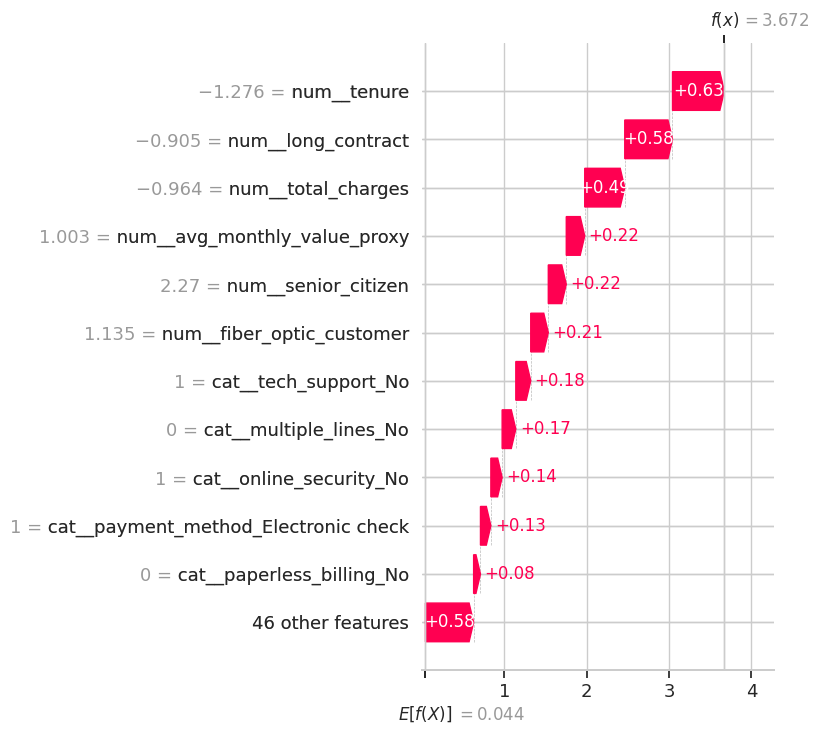

In [46]:
shap.plots.waterfall(shap_explanation[high_risk_churn_idx], max_display=12, show=False)
plt.tight_layout()
save_fig("explainability_06_waterfall_high_risk_customer.png")
plt.show()

In [47]:
print("Raw feature view — low-risk retained customer")
display(test_analysis.loc[[low_risk_retained_idx], X_test.columns.tolist() + ["churn", "score"]])

print("\nTop positive contributors (increase churn risk)")
display(low_risk_local.head(10))

print("\nTop negative contributors (reduce churn risk)")
display(low_risk_local.tail(10).sort_values("shap_value"))

Raw feature view — low-risk retained customer


,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,tenure_group,long_contract,high_monthly_charges,avg_monthly_value_proxy,subscribed_services_count,payment_group,has_security_bundle,fiber_optic_customer,churn,score
236,Male,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.8000,"1,468.7500",long_term,1,0,20.3993,0,automatic,0,0,0,0.0020



Top positive contributors (increase churn risk)


,feature,value,shap_value
8,num__has_security_bundle,-1.0757,0.1098
36,cat__streaming_tv_No,0.0000,0.0358
45,cat__paperless_billing_No,0.0000,0.0248
35,cat__tech_support_Yes,0.0000,0.0175
46,cat__paperless_billing_Yes,1.0000,0.0150
50,cat__payment_method_Mailed check,0.0000,0.0132
15,cat__dependents_Yes,0.0000,0.0079
13,cat__partner_Yes,0.0000,0.0073
14,cat__dependents_No,1.0000,0.0051
56,cat__payment_group_mailed_check,0.0000,0.0032



Top negative contributors (reduce churn risk)


,feature,value,shap_value
1,num__tenure,1.6101,-1.6530
6,num__long_contract,1.1054,-0.9330
4,num__avg_monthly_value_proxy,-1.4646,-0.5719
3,num__total_charges,-0.3594,-0.3933
2,num__monthly_charges,-1.4850,-0.3725
44,cat__contract_Two year,1.0000,-0.3161
33,cat__tech_support_No,0.0000,-0.2675
5,num__subscribed_services_count,-1.1008,-0.2291
24,cat__online_security_No,0.0000,-0.2087
49,cat__payment_method_Electronic check,0.0000,-0.1784


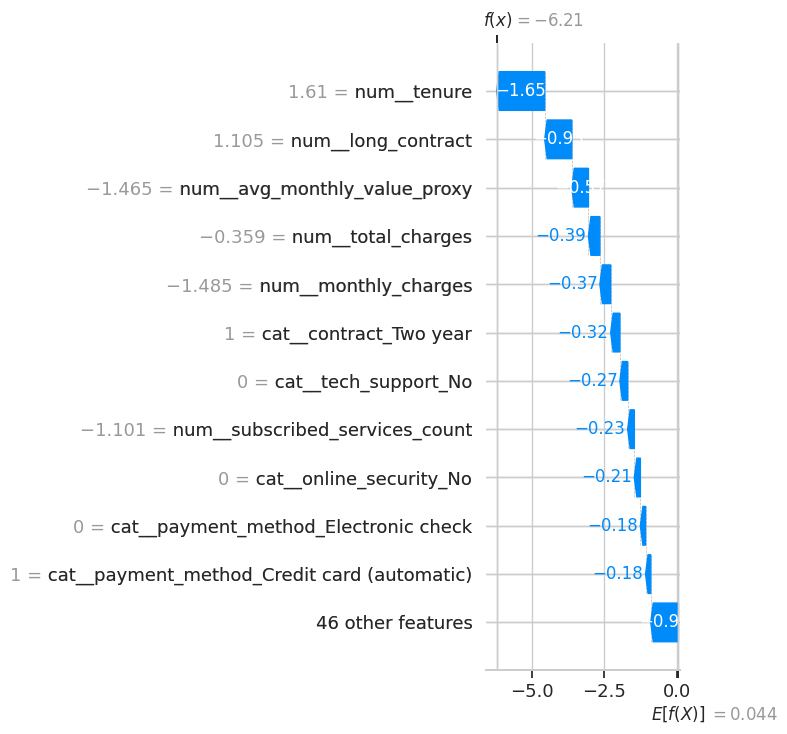

In [48]:
shap.plots.waterfall(shap_explanation[low_risk_retained_idx], max_display=12, show=False)
plt.tight_layout()
save_fig("explainability_07_waterfall_low_risk_customer.png")
plt.show()

## 9. Explanation summary

At this stage, we combine:
- model feature importance,
- global SHAP importance,
- cohort analysis,
- and local customer explanations.

This makes it possible to distinguish between:
- globally important risk drivers,
- globally important protective factors,
- and the specific combination of factors that affect individual customers.

In [49]:
top_global_features = global_shap_importance.head(12).copy()
top_global_features

,feature,mean_abs_shap,feature_family
6,num__long_contract,0.6495,contract
1,num__tenure,0.4093,tenure
3,num__total_charges,0.2167,billing
9,num__fiber_optic_customer,0.2130,internet
24,cat__online_security_No,0.1924,support_security
33,cat__tech_support_No,0.1898,support_security
2,num__monthly_charges,0.1896,billing
4,num__avg_monthly_value_proxy,0.1748,billing
49,cat__payment_method_Electronic check,0.1346,payment
44,cat__contract_Two year,0.1323,contract


## 10. Business interpretation

### Factors that increase churn risk
The explainability results show that the strongest churn-increasing patterns are associated with:
- lack of long-term commitment,
- short tenure,
- fiber optic service,
- absence of online security,
- absence of tech support,
- higher monthly and cumulative billing signals,
- electronic check payment behavior.

At the feature level, the strongest global signals include:
- `long_contract` (in its absence),
- `tenure`,
- `total_charges`,
- `fiber_optic_customer`,
- `online_security_No`,
- `tech_support_No`,
- `monthly_charges`,
- `avg_monthly_value_proxy`,
- `payment_method_Electronic check`,
- contract-related indicators.

### Factors that reduce churn risk
The strongest churn-reducing patterns are associated with:
- long contractual commitment,
- longer tenure,
- two-year contracts,
- lower monthly charges,
- non-fiber configurations,
- presence of support/security services,
- non-electronic-check payment behavior.

### Sensitive customer profiles
The most sensitive customers are clearly concentrated in profiles combining several risk signals at once.

In the top 10% highest-risk group:
- 100.00% are on month-to-month contracts,
- 89.62% use fiber optic internet,
- 77.36% use electronic check,
- 96.23% have no tech support,
- 98.11% have no online security,
- 91.51% are new customers,
- and the observed churn rate reaches 72.64%.

By contrast, the bottom 10% lowest-risk group is characterized by:
- 89.62% two-year contracts,
- 100.00% long contracts,
- 88.68% long-term customers,
- only 5.66% fiber optic users,
- almost no electronic check users (0.94%),
- and an observed churn rate of 0.00%.

Overall, the model is learning highly interpretable churn patterns that are strongly aligned with customer lifecycle, commitment level, support configuration, and payment behavior.

## 10.1 Practical interpretation note

Because some engineered features overlap with original variables, the final interpretation should be read at the level of **customer patterns** rather than isolated individual columns.

For example, if both `long_contract` and `contract_Two year` appear important, the main business message is the same: **stronger commitment reduces churn risk**.

## 11. Recommendations for business action

The explainability results suggest several concrete retention directions:

1. Prioritize new customers and month-to-month customers for early retention interventions, since they are strongly overrepresented in the highest-risk group.
2. Investigate the churn dynamics of fiber optic customers, especially when they also lack tech support or online security.
3. Target electronic-check customers with dedicated retention or payment migration actions, since this payment behavior is consistently associated with higher risk.
4. Promote stickier retention levers such as longer contracts and support/security add-ons when relevant.
5. Use the model as a prioritization tool for retention campaigns, focusing first on the top-risk deciles rather than treating churn prediction only as a binary classification task.

In [50]:
global_shap_importance.to_csv(REPORTS_DIR / "global_shap_importance.csv", index=False)
global_shap_family.to_csv(REPORTS_DIR / "global_shap_importance_by_theme.csv", index=False)
model_importance_df.to_csv(REPORTS_DIR / "model_feature_importance.csv", index=False)
family_importance_df.to_csv(REPORTS_DIR / "model_feature_importance_by_theme.csv", index=False)
cohort_summary.to_csv(REPORTS_DIR / "risk_cohort_summary.csv", index=False)
profile_summary.to_csv(REPORTS_DIR / "risk_profile_summary.csv", index=False)
high_risk_local.to_csv(REPORTS_DIR / "local_explanation_high_risk_customer.csv", index=False)
low_risk_local.to_csv(REPORTS_DIR / "local_explanation_low_risk_customer.csv", index=False)

print("Saved explainability outputs in:", REPORTS_DIR)

Saved explainability outputs in: ../reports


## 12. Key takeaways

### Main outcomes
1. The final XGBoost model was explained using both built-in feature importance and SHAP-based analysis.
2. Contract structure is the strongest explanatory theme, followed by tenure, billing, support/security variables, internet configuration, and payment behavior.
3. The highest-risk customers are strongly concentrated in a clear churn-prone profile: new customers on month-to-month contracts, often with fiber optic service, electronic check payment, and no support/security services.
4. The lowest-risk customers show the opposite pattern: long tenure, long contracts, low-risk payment behavior, and very low observed churn.
5. The explainability results confirm that the model is learning business-plausible churn patterns rather than arbitrary correlations.
6. The outputs generated in this notebook can directly support the dashboard, README, and final business recommendations.

### Final business message
The model suggests that churn is primarily driven by weak contractual commitment, early customer lifecycle stage, costly or unstable service configurations, and lack of support/security services. These patterns are interpretable enough to guide targeted retention actions.

### Next step
The next project step is the final restitution layer:
- Streamlit dashboard,
- README,
- business recommendations,
- final repository cleanup.